In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/ToyotaCorolla - MLR.csv")   # change path if needed
df.head()


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [7]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


visualization

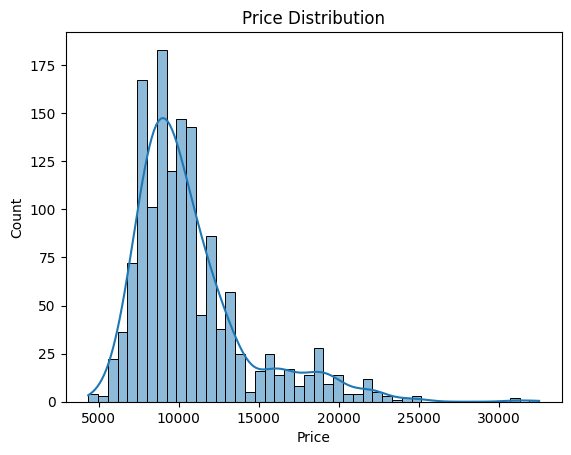

In [8]:
sns.histplot(df['Price'], kde=True)
plt.title("Price Distribution")
plt.show()


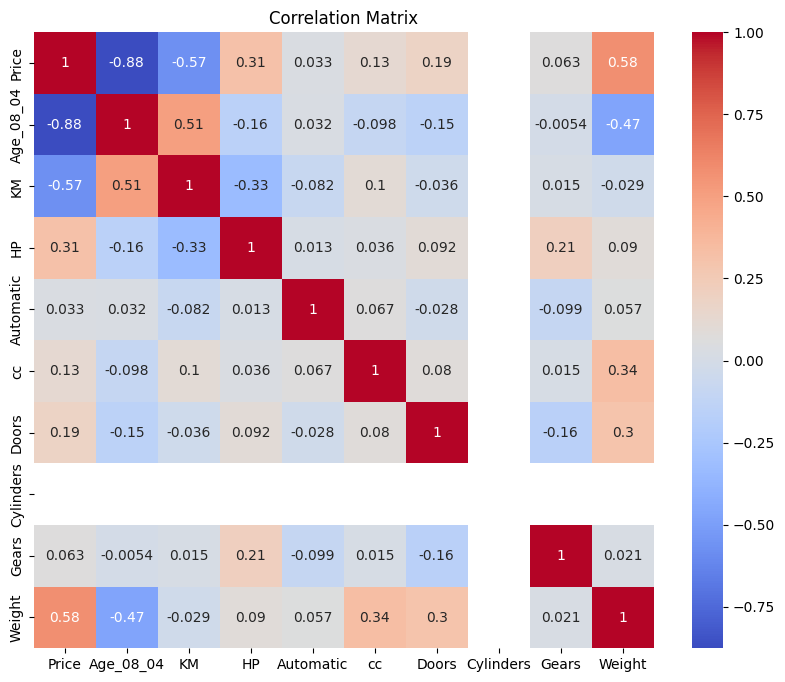

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

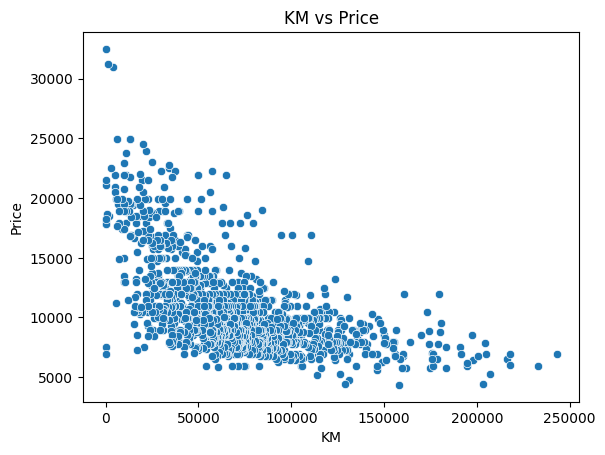

In [11]:
sns.scatterplot(x='KM', y='Price', data=df)
plt.title("KM vs Price")
plt.show()


#Data Preprocessing

In [13]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

In [15]:
X = df.drop('Price', axis=1)
y = df['Price']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [18]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)


In [19]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model1.coef_
})
coef_df


,Feature,Coefficient
0,Age_08_04,-1.208305e+02
1,KM,-1.623141e-02
2,HP,1.403948e+01
3,Automatic,1.488309e+02
4,cc,-3.037219e-02
5,Doors,-6.031097e+01
6,Cylinders,-1.620037e-12
7,Gears,5.516007e+02
8,Weight,2.588496e+01
9,Fuel_Type_Diesel,-6.854876e+01


In [21]:
X2 = df[['Age_08_04','KM','HP','Weight']]
y2 = df['Price']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

y_pred2 = model2.predict(X2_test)


In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X3_train, X3_test, y3_train, y3_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X3_train, y3_train)

y_pred3 = model3.predict(X3_test)


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [25]:
def evaluate(y_test, y_pred):
    print("MAE :", mean_absolute_error(y_test, y_pred))
    print("MSE :", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2  :", r2_score(y_test, y_pred))


In [26]:
print("Model 1 Performance")
evaluate(y_test, y_pred1)

print("\nModel 2 Performance")
evaluate(y2_test, y_pred2)

print("\nModel 3 Performance")
evaluate(y3_test, y_pred3)


Model 1 Performance
MAE : 990.8872739193926
MSE : 2203043.8231437025
RMSE: 1484.2654153296514
R2  : 0.8348888040611082

Model 2 Performance
MAE : 1001.2017466053621
MSE : 1993321.0129730713
RMSE: 1411.85020911323
R2  : 0.8506068681500583

Model 3 Performance
MAE : 990.8872739193968
MSE : 2203043.823143705
RMSE: 1484.2654153296521
R2  : 0.834888804061108


In [27]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_lasso = lasso.predict(X_test)

print("Lasso Performance")
evaluate(y_test, y_lasso)


Lasso Performance
MAE : 990.8940127223727
MSE : 2202270.2600246817
RMSE: 1484.0048045827486
R2  : 0.8349467801805


In [28]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_ridge = ridge.predict(X_test)

print("Ridge Performance")
evaluate(y_test, y_ridge)


Ridge Performance
MAE : 990.7338342026006
MSE : 2199746.3702333393
RMSE: 1483.1541963778882
R2  : 0.8351359377712336


#interview questions

#1.What is Normalization & Standardization and how is it helpful?

*Normalization - it  is a technique used to scale data between 0 and 1.
 formula : Xnorm = X - Xmin / (Xmax - Xmin)

*Standardization - transforms data so that it has:
Mean = 0,
Standard deviation = 1

 formula : Xstd = X-mean / sigma


#2.What techniques can be used to address multicollinearity in multiple linear regression?

*Removing one of the highly correlated features based on correlation analysis.

*Using Variance Inflation Factor (VIF) to detect and drop variables with high VIF values.

*Applying Ridge Regression to shrink coefficient values and reduce multicollinearity effects.

*Using Lasso Regression, which performs feature selection by setting some coefficients to zero.

*Applying Principal Component Analysis (PCA) to transform correlated variables into uncorrelated components.

*Increasing the sample size to improve model stability.